───────────────────────────────────────────────────────
Single-point lookup
───────────────────────────────────────────────────────
  T = 10.0 °C,  S = 30.0 ‰,  λ = 550.0 nm
  n = 1.340721
  (pure water at same T, λ: n = 1.335021)



Text(0.5, 1.0, 'n(T, S) at λ = 550 nm')

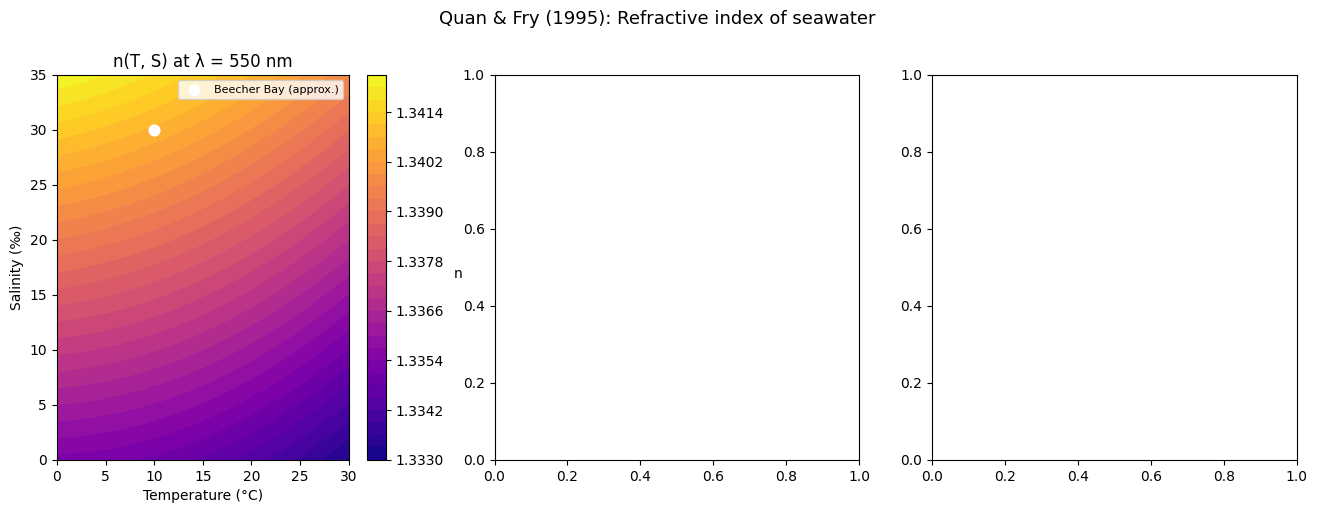

In [1]:
"""
Quan & Fry (1995) refractive index of seawater
Appl. Opt. 34(18), 3477-3480
doi: 10.1364/AO.34.003477

Valid ranges:
  Temperature T : 0 – 30 °C
  Salinity    S : 0 – 35 ‰ (ppt)
  Wavelength  λ : 400 – 700 nm
  Pressure      : atmospheric (depth < ~100 m)
"""

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ── Coefficients (Table 1 of Quan & Fry 1995) ─────────────────────────────────
A = [
    1.31405,       # a0  — pure water base index
    1.779e-4,      # a1  — salinity linear
   -1.05e-6,       # a2  — salinity × T
    1.6e-8,        # a3  — salinity × T²
   -2.02e-6,       # a4  — pure water T²
   15.868,         # a5  — dispersion 1/λ base
    0.01155,       # a6  — dispersion 1/λ salinity
   -0.00423,       # a7  — dispersion 1/λ temperature
   -4382.0,        # a8  — dispersion 1/λ²
    1.1455e6,      # a9  — dispersion 1/λ³
]


def n_seawater(T, S, lam):
    """
    Refractive index of seawater relative to air.

    Parameters
    ----------
    T   : float or array-like, Temperature in °C  (0 – 30)
    S   : float or array-like, Salinity in ‰       (0 – 35)
    lam : float or array-like, Wavelength in nm    (400 – 700)

    Returns
    -------
    n : same shape as inputs (broadcast-compatible)
    """
    T, S, lam = np.asarray(T, float), np.asarray(S, float), np.asarray(lam, float)
    n = (A[0]
         + (A[1] + A[2]*T + A[3]*T**2) * S
         + A[4]*T**2
         + (A[5] + A[6]*S + A[7]*T) / lam
         + A[8] / lam**2
         + A[9] / lam**3)
    return n


def warn_out_of_range(T, S, lam):
    msgs = []
    if np.any(np.asarray(T) < 0) or np.any(np.asarray(T) > 30):
        msgs.append("Temperature outside 0–30 °C")
    if np.any(np.asarray(S) < 0) or np.any(np.asarray(S) > 35):
        msgs.append("Salinity outside 0–35 ‰")
    if np.any(np.asarray(lam) < 400) or np.any(np.asarray(lam) > 700):
        msgs.append("Wavelength outside 400–700 nm")
    for m in msgs:
        print(f"  ⚠  Warning: {m} — extrapolation beyond validated range")


# ── 1. Single-point lookup ─────────────────────────────────────────────────────
print("─" * 55)
print("Single-point lookup")
print("─" * 55)

# Beecher Bay conditions (approx.)
T_site, S_site, lam_green = 10.0, 30.0, 550.0
n_val = n_seawater(T_site, S_site, lam_green)
print(f"  T = {T_site} °C,  S = {S_site} ‰,  λ = {lam_green} nm")
print(f"  n = {n_val:.6f}")
print(f"  (pure water at same T, λ: n = {n_seawater(T_site, 0, lam_green):.6f})")
print()


# ── 2. Grid sweep: T × S at fixed λ ───────────────────────────────────────────
T_range = np.linspace(0, 30, 61)    # 0.5 °C steps
S_range = np.linspace(0, 35, 71)    # 0.5 ‰ steps

T_grid, S_grid = np.meshgrid(T_range, S_range, indexing='ij')
n_grid = n_seawater(T_grid, S_grid, lam_green)


# ── 3. Dispersion sweep: n vs λ for several T/S combinations ──────────────────
lam_range = np.linspace(400, 700, 301)
conditions = [
    (5,  0,  "T=5°C,  S=0‰  (cold fresh)"),
    (10, 30, "T=10°C, S=30‰ (Beecher Bay)"),
    (20, 35, "T=20°C, S=35‰ (warm ocean)"),
    (30, 35, "T=30°C, S=35‰ (tropical)"),
]


# ── Plotting ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Quan & Fry (1995): Refractive index of seawater", fontsize=13, y=1.01)

# — Plot 1: heatmap n(T, S) at λ = 550 nm —
ax = axes[0]
im = ax.contourf(T_range, S_range, n_grid.T, levels=30, cmap="plasma")
cbar = fig.colorbar(im, ax=ax)
cbar.set_label("n", rotation=0, labelpad=10)

# Mark Beecher Bay site
ax.scatter([T_site], [S_site], color="white", s=60, zorder=5, label="Beecher Bay (approx.)")
ax.legend(fontsize=8, loc="upper right")

ax.set_xlabel("Temperature (°C)")
ax.set_ylabel("Salinity (‰)")
ax.set_title(f"n(T, S) at λ = {lam_green:.0f} nm")


In [2]:
lam_standard =  589.3 #nm - sodium-dline

##set1
T1=10.5 #celcius
S1 = 27.4 #percent
n1 = n_seawater(T1, S1, lam_standard)
print(f"n1 = {n1:.6f}")

##set2
T2=16.0 #celcius
S2 = 27.6 #percent
n2 = n_seawater(T2, S2, lam_standard)
print(f"n2 = {n2:.6f}")

n1 = 1.338816
n2 = 1.338424
